In [5]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler, QuantileTransformer

In [6]:
dataset = pd.read_csv("../../data/processed_dataset/GLCM/unique_crop_window_glcm_radiomics_dataset_cleaned.csv")
dataset = dataset.drop(columns=['mask_path', 'ct_image_path'])
dataset.describe()

,cm_joint_max_d1_2d_avg_fbn_n16,cm_joint_avg_d1_2d_avg_fbn_n16,cm_joint_var_d1_2d_avg_fbn_n16,cm_joint_entr_d1_2d_avg_fbn_n16,cm_diff_avg_d1_2d_avg_fbn_n16,cm_diff_var_d1_2d_avg_fbn_n16,cm_diff_entr_d1_2d_avg_fbn_n16,cm_sum_avg_d1_2d_avg_fbn_n16,cm_sum_var_d1_2d_avg_fbn_n16,cm_sum_entr_d1_2d_avg_fbn_n16,...,cm_inv_var_d1_2d_avg_fbn_n16,cm_corr_d1_2d_avg_fbn_n16,cm_auto_corr_d1_2d_avg_fbn_n16,cm_clust_tend_d1_2d_avg_fbn_n16,cm_clust_shade_d1_2d_avg_fbn_n16,cm_clust_prom_d1_2d_avg_fbn_n16,cm_info_corr1_d1_2d_avg_fbn_n16,cm_info_corr2_d1_2d_avg_fbn_n16,z_middle_global,patient_id
count,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000,...,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000,50718.000000
mean,0.094529,9.362274,8.142182,5.634360,1.783413,2.698366,2.316070,18.724549,26.033622,3.824655,...,0.383179,0.525192,97.047268,26.033622,-65.046250,3507.181230,-0.196117,0.759051,236.790193,4586.748393
std,0.100542,2.124711,6.118373,0.945260,0.748826,1.731632,0.481363,4.249423,24.289627,0.464296,...,0.070904,0.246768,38.753112,24.289627,275.047609,6572.631285,0.134537,0.155834,73.729660,2665.756145
min,0.017701,1.024468,0.104143,0.135078,0.004939,0.004913,0.044730,2.048936,0.235483,0.121420,...,0.000178,-0.749446,1.133153,0.235483,-2540.849712,0.333175,-0.972331,0.080654,3.000000,1.000000
25%,0.039923,8.349708,4.813526,5.235290,1.265414,1.531290,2.043110,16.699415,13.591329,3.656993,...,0.340054,0.329408,73.636009,13.591329,-82.372399,781.901216,-0.264857,0.644705,207.000000,2736.000000
50%,0.057066,9.471946,6.429940,5.900136,1.791690,2.386894,2.414233,18.943891,18.373303,3.912975,...,0.387566,0.512660,93.990842,18.373303,-26.243933,1366.647402,-0.162632,0.783422,248.000000,4467.000000
75%,0.098208,10.656699,9.196347,6.306914,2.240871,3.413898,2.666216,21.313398,28.033018,4.104418,...,0.437580,0.717999,118.462872,28.033018,-0.736845,2898.093262,-0.091921,0.892043,285.000000,6189.000000
max,0.985990,15.881891,55.642311,7.271003,8.000000,49.000000,3.460872,31.763782,222.525594,4.845940,...,0.591890,0.999942,252.248077,222.525594,2434.705546,65884.309575,-0.013264,0.997666,672.000000,9901.000000


In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 50718 entries, 0 to 50717
Data columns (total 27 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   cm_joint_max_d1_2d_avg_fbn_n16          50718 non-null  float64
 1   cm_joint_avg_d1_2d_avg_fbn_n16          50718 non-null  float64
 2   cm_joint_var_d1_2d_avg_fbn_n16          50718 non-null  float64
 3   cm_joint_entr_d1_2d_avg_fbn_n16         50718 non-null  float64
 4   cm_diff_avg_d1_2d_avg_fbn_n16           50718 non-null  float64
 5   cm_diff_var_d1_2d_avg_fbn_n16           50718 non-null  float64
 6   cm_diff_entr_d1_2d_avg_fbn_n16          50718 non-null  float64
 7   cm_sum_avg_d1_2d_avg_fbn_n16            50718 non-null  float64
 8   cm_sum_var_d1_2d_avg_fbn_n16            50718 non-null  float64
 9   cm_sum_entr_d1_2d_avg_fbn_n16           50718 non-null  float64
 10  cm_energy_d1_2d_avg_fbn_n16             50718 non-null  float64
 11  

In [8]:
# 1. Patient Count (Crucial for splitting strategy)
print(f"Unique Patients: {dataset['patient_id'].nunique()}")

# 2. Target Variance (Crucial for Loss Scaling)
# We need to know the mean and std of each feature to normalize the targets
stats = dataset.iloc[:, 0:24].describe().loc[['mean', 'std']].T
print("\n--- Target Statistics (Raw) ---")
print(stats.head(10)) 

# 3. Check for NaN/Inf (Crucial for Stability)
print(f"\nTotal NaNs in features: {dataset.iloc[:, 0:24].isnull().sum().sum()}")
print(f"Total Infs in features: {dataset.isin([np.inf, -np.inf]).sum().sum()}")

Unique Patients: 6900

--- Target Statistics (Raw) ---
                                      mean        std
cm_joint_max_d1_2d_avg_fbn_n16    0.094529   0.100542
cm_joint_avg_d1_2d_avg_fbn_n16    9.362274   2.124711
cm_joint_var_d1_2d_avg_fbn_n16    8.142182   6.118373
cm_joint_entr_d1_2d_avg_fbn_n16   5.634360   0.945260
cm_diff_avg_d1_2d_avg_fbn_n16     1.783413   0.748826
cm_diff_var_d1_2d_avg_fbn_n16     2.698366   1.731632
cm_diff_entr_d1_2d_avg_fbn_n16    2.316070   0.481363
cm_sum_avg_d1_2d_avg_fbn_n16     18.724549   4.249423
cm_sum_var_d1_2d_avg_fbn_n16     26.033622  24.289627
cm_sum_entr_d1_2d_avg_fbn_n16     3.824655   0.464296

Total NaNs in features: 0
Total Infs in features: 0


In [9]:
dataset = dataset.reset_index(drop=False)

In [10]:
print(dataset.groupby("patient_id").size().describe())

count    6900.000000
mean        7.350435
std         1.432374
min         1.000000
25%         7.000000
50%         8.000000
75%         8.000000
max        12.000000
dtype: float64


In [11]:
for i in range(5):
    print(i, dataset.iloc[i+10]['index'], dataset.iloc[i+10]['patient_id'])

0 10.0 2594.0
1 11.0 2594.0
2 12.0 2594.0
3 13.0 2594.0
4 14.0 2594.0


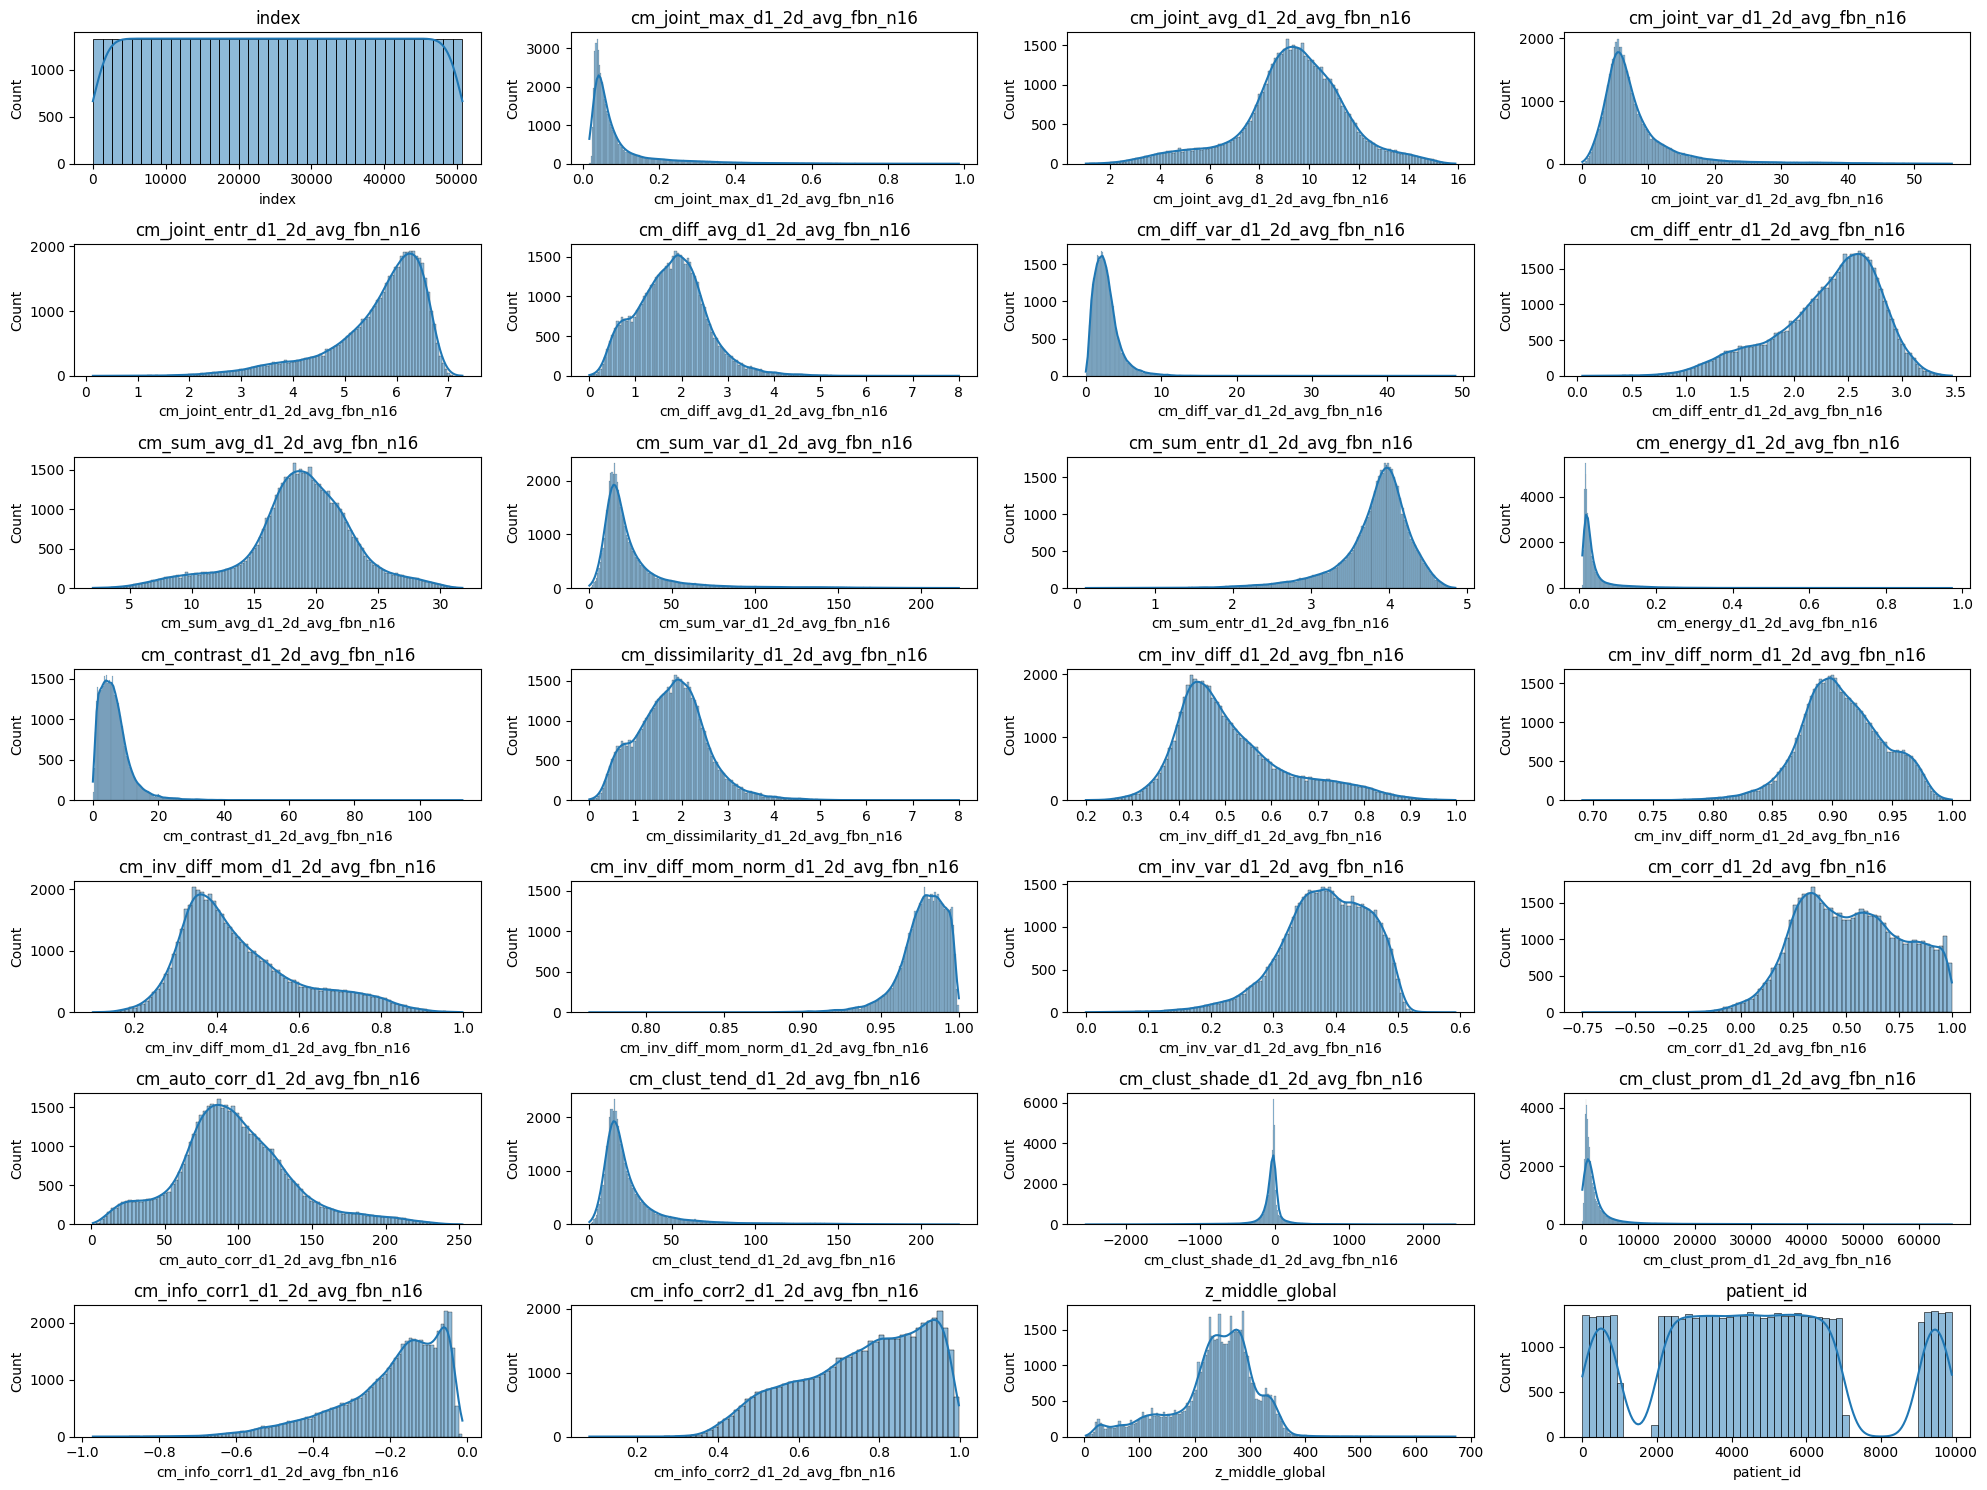

In [12]:
cols = dataset.columns[:]

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(dataset[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [13]:
QUANTILE_FEATURES = [
    'cm_joint_max_d1_2d_avg_fbn_n16',
    'cm_joint_var_d1_2d_avg_fbn_n16',
    'cm_diff_var_d1_2d_avg_fbn_n16',
    'cm_sum_var_d1_2d_avg_fbn_n16',
    'cm_energy_d1_2d_avg_fbn_n16',
    'cm_contrast_d1_2d_avg_fbn_n16',
    'cm_dissimilarity_d1_2d_avg_fbn_n16',
    'cm_corr_d1_2d_avg_fbn_n16',
    'cm_clust_tend_d1_2d_avg_fbn_n16',
    'cm_clust_shade_d1_2d_avg_fbn_n16',
    'cm_clust_prom_d1_2d_avg_fbn_n16',
    'cm_info_corr1_d1_2d_avg_fbn_n16',
    'cm_info_corr2_d1_2d_avg_fbn_n16'
]
POWER_FEATURES = [
    'cm_joint_avg_d1_2d_avg_fbn_n16',
    'cm_joint_entr_d1_2d_avg_fbn_n16',
    'cm_diff_avg_d1_2d_avg_fbn_n16',
    'cm_diff_entr_d1_2d_avg_fbn_n16',
    'cm_sum_avg_d1_2d_avg_fbn_n16',
    'cm_sum_entr_d1_2d_avg_fbn_n16',
    'cm_inv_diff_d1_2d_avg_fbn_n16',
    'cm_inv_diff_norm_d1_2d_avg_fbn_n16',
    'cm_inv_diff_mom_d1_2d_avg_fbn_n16',
    'cm_inv_diff_mom_norm_d1_2d_avg_fbn_n16',
    'cm_inv_var_d1_2d_avg_fbn_n16',
    'cm_auto_corr_d1_2d_avg_fbn_n16'
]

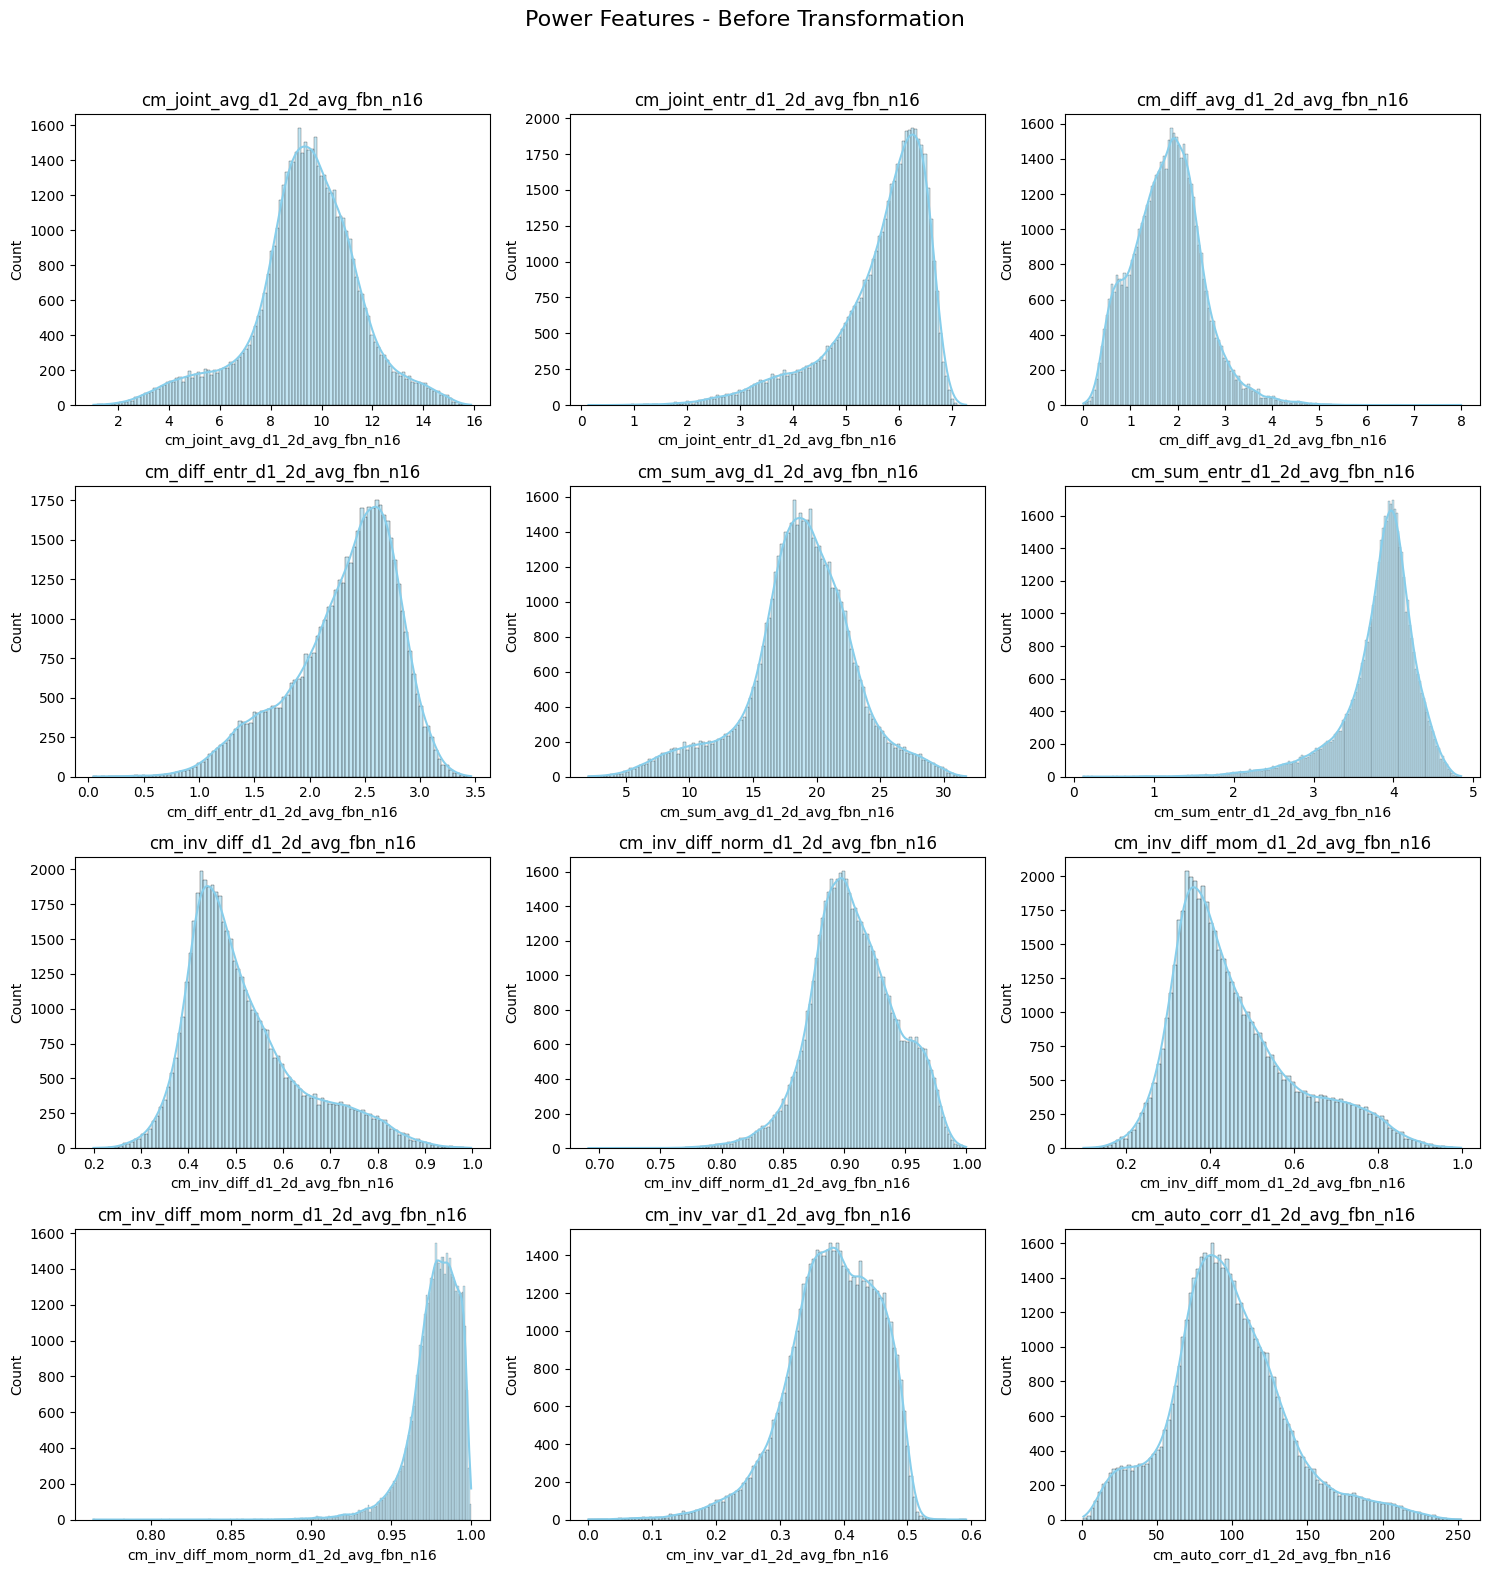

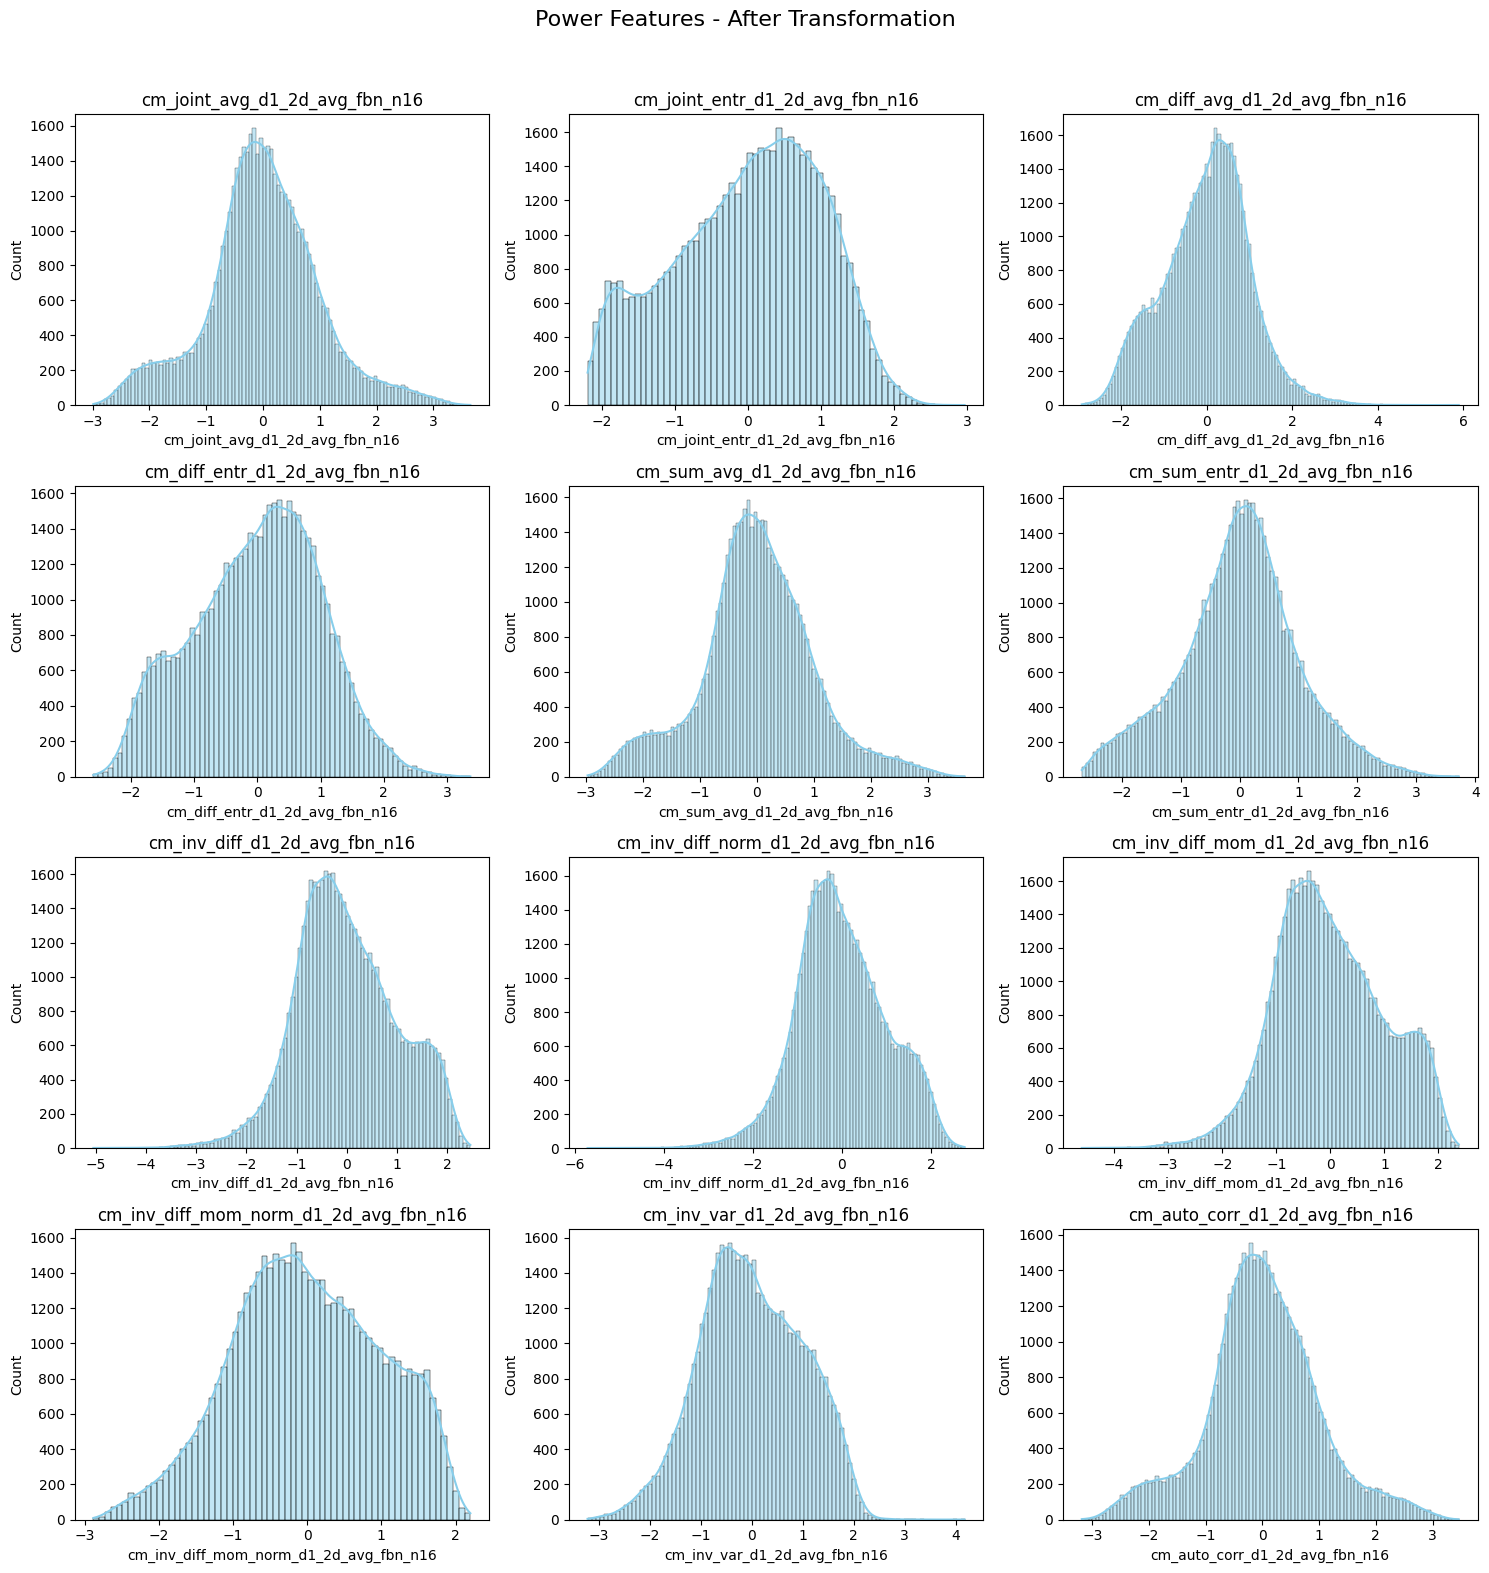

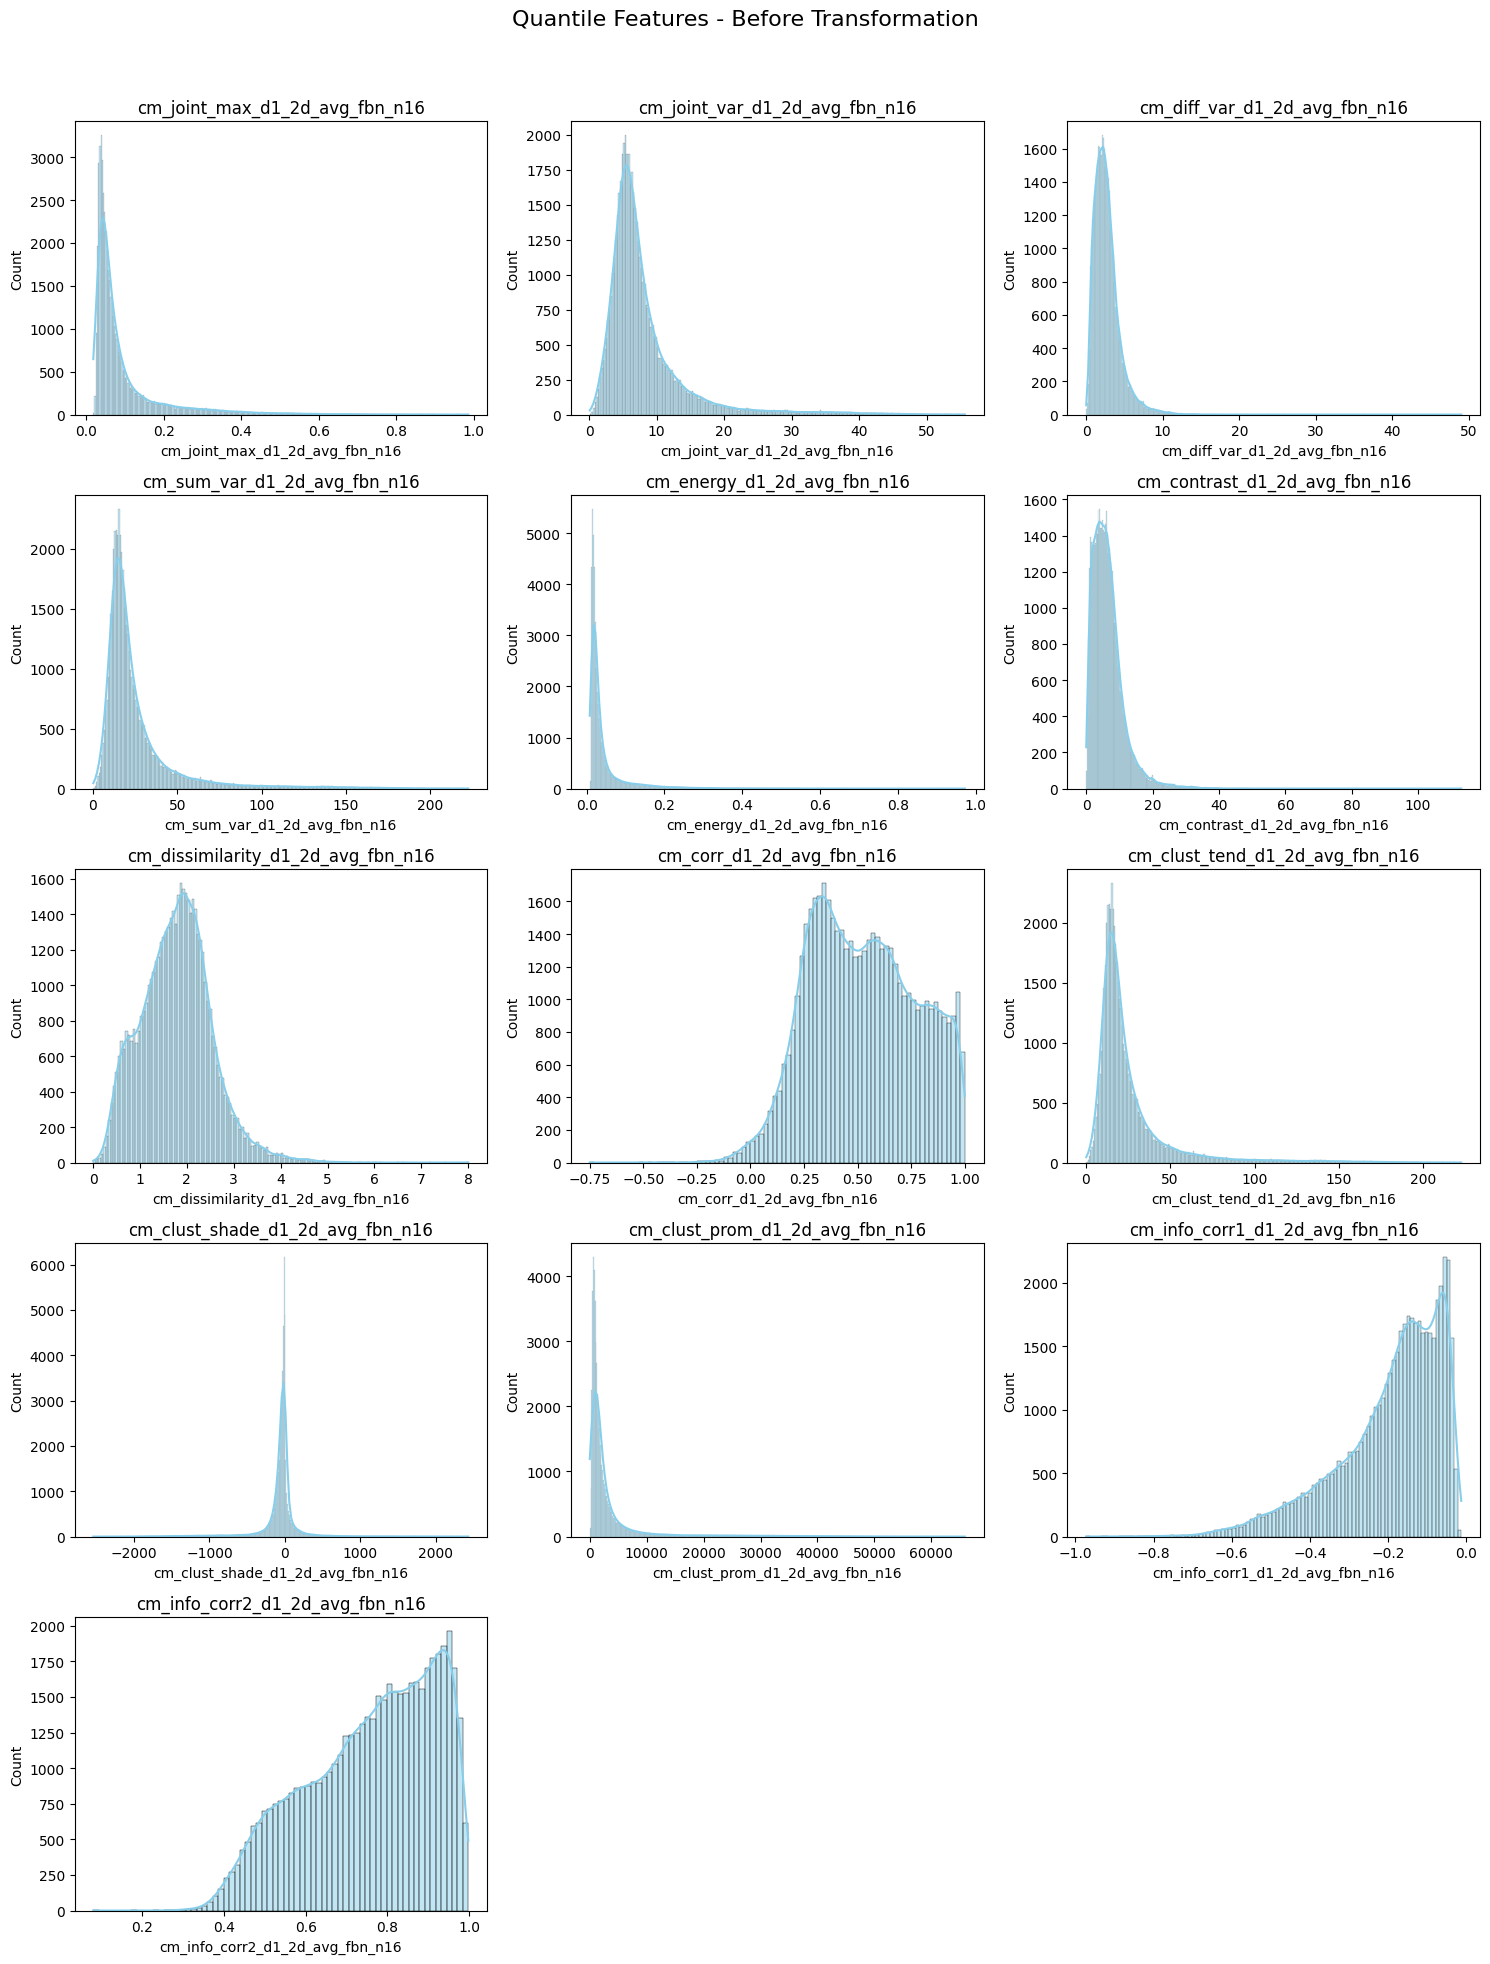

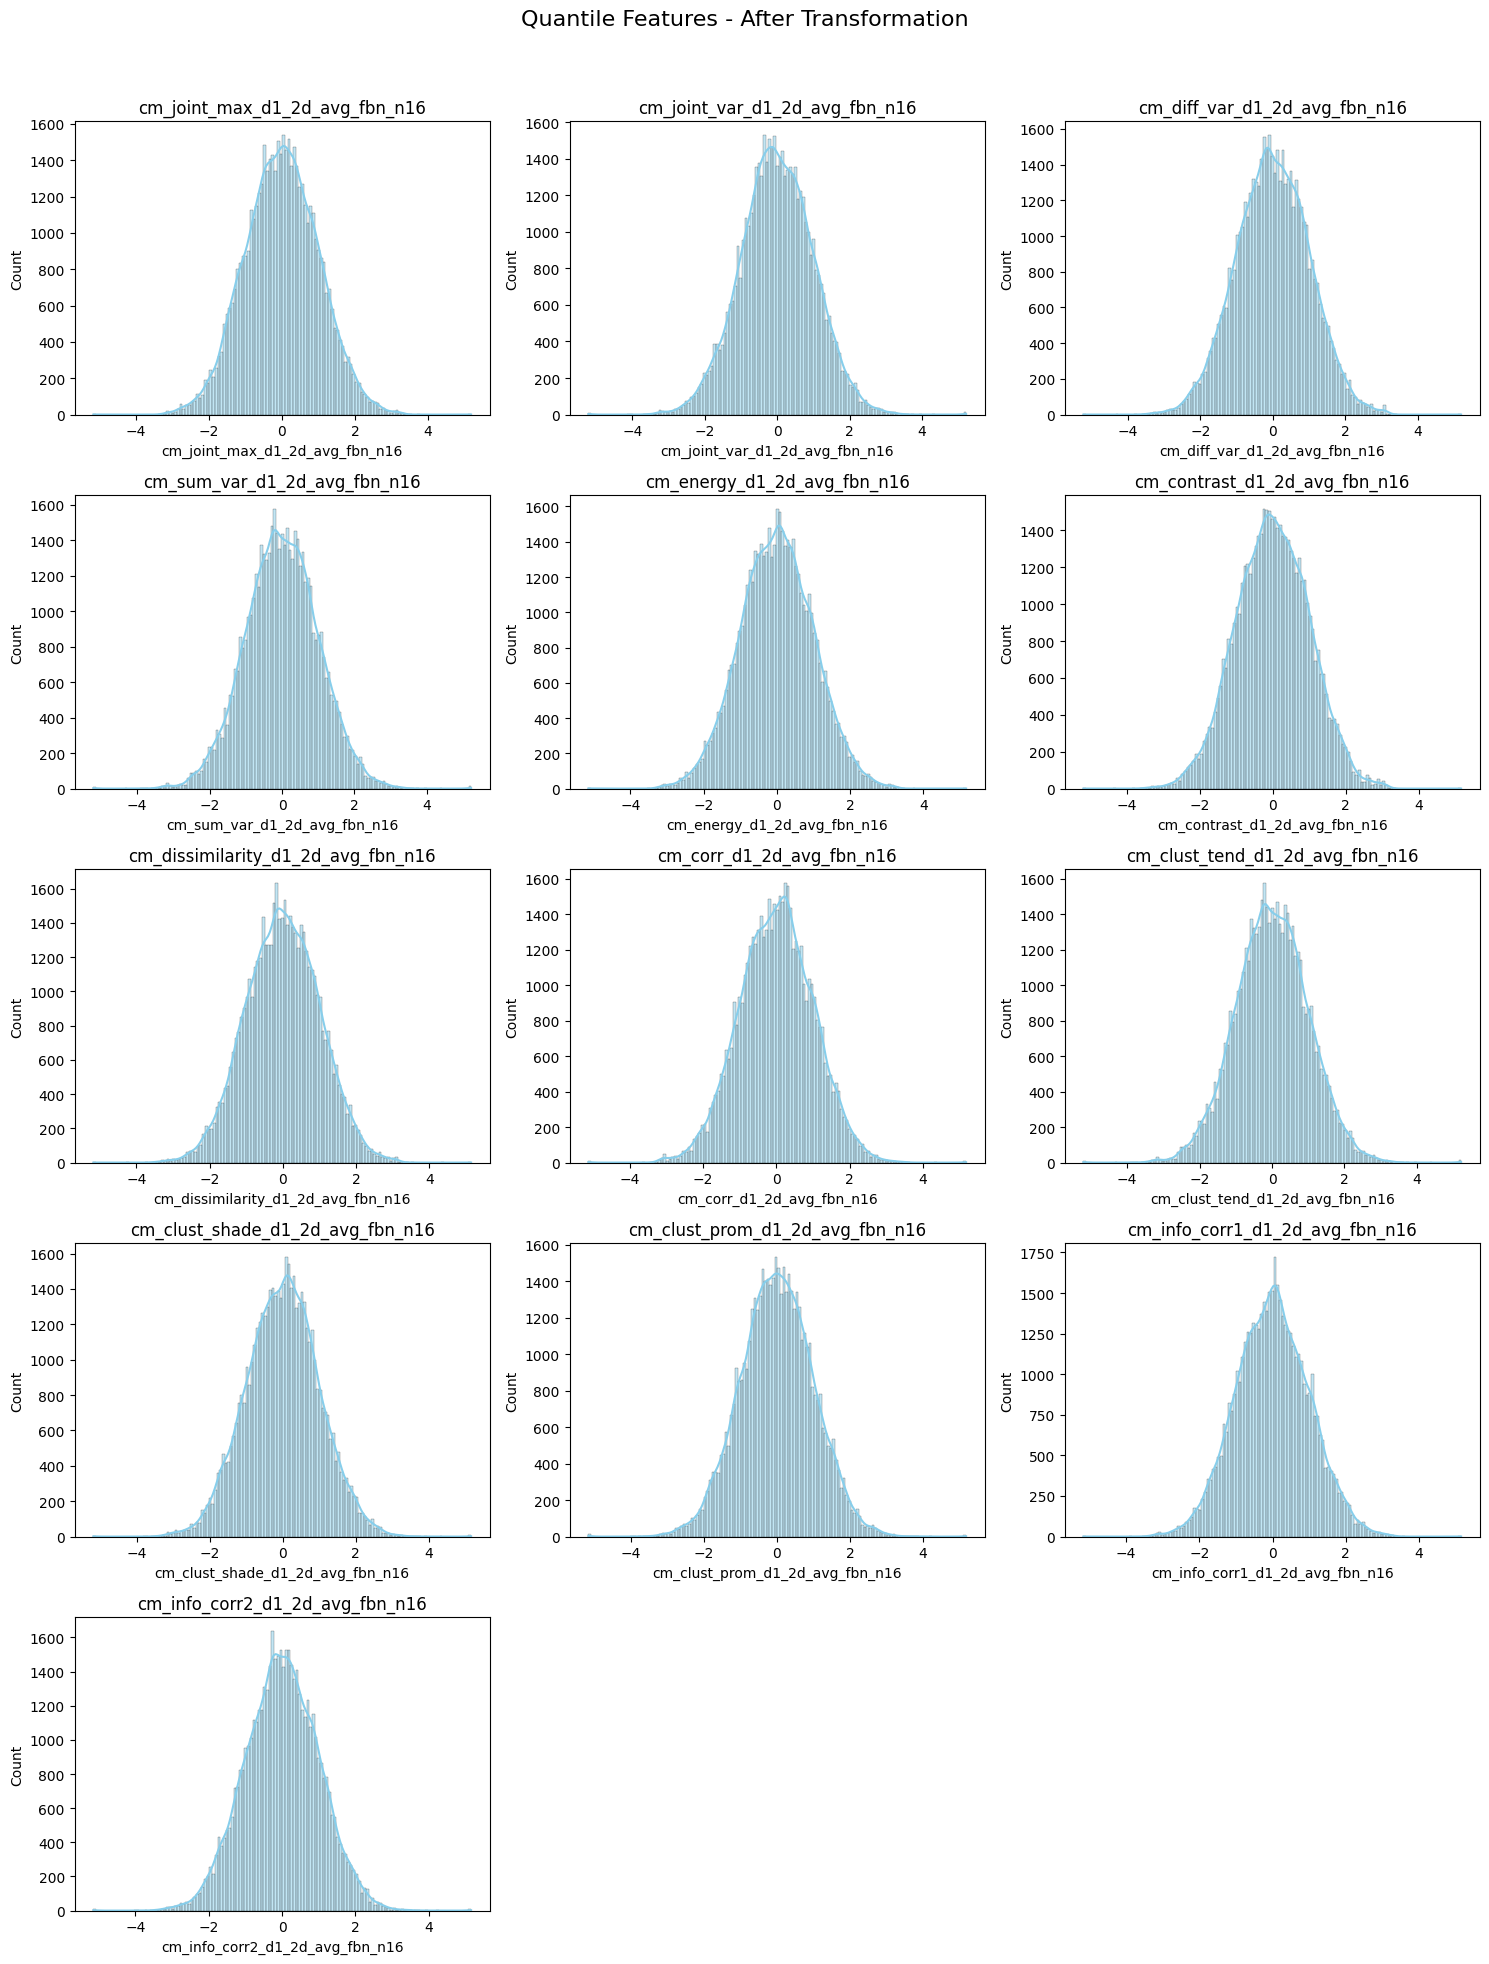

In [14]:
dataset_orig = dataset.copy()  # keep original

# Transform Power Features
pt_yeo = PowerTransformer(method='yeo-johnson', standardize=False)
scaler_power = StandardScaler()
dataset[POWER_FEATURES] = scaler_power.fit_transform(pt_yeo.fit_transform(dataset[POWER_FEATURES]))

# Transform Quantile Features
qt = QuantileTransformer(output_distribution='normal', random_state=42, n_quantiles=1000)
scaler_quantile = StandardScaler()
dataset[QUANTILE_FEATURES] = scaler_quantile.fit_transform(qt.fit_transform(dataset[QUANTILE_FEATURES]))

# --- Function to plot each feature individually in a figure ---
def plot_features_separate(dataset_data, features, title):
    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()
    
    for i, f in enumerate(features):
        sns.histplot(dataset_data[f], kde=True, color='skyblue', ax=axes[i])
        axes[i].set_title(f"{f}")
    
    # Remove empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- Plot Power Features ---
plot_features_separate(dataset_orig, POWER_FEATURES, "Power Features - Before Transformation")
plot_features_separate(dataset, POWER_FEATURES, "Power Features - After Transformation")

# --- Plot Quantile Features ---
plot_features_separate(dataset_orig, QUANTILE_FEATURES, "Quantile Features - Before Transformation")
plot_features_separate(dataset, QUANTILE_FEATURES, "Quantile Features - After Transformation")